In [55]:
import os
from dotenv import load_dotenv

In [58]:
load_dotenv()

True

In [62]:
print(os.getenv("GOOGLE_API_KEY"))
print(os.getenv("NOTION_API_KEY"))
print(os.getenv("NOTION_CALENDAR_DB_ID"))
print(os.getenv("NOTION_NOTES_DB_ID"))

In [63]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [64]:
llm = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash-lite')

In [65]:
llm.invoke('hi there')

AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPQJRPJKggxmjJM2dz+wTf5ghwTc713SXonaLi0sEujx4ho8TQyE7S6H4XsADSaMSJHQVS6QSUXt2Eepfk6NooyoaQhH/sQeTtpPtgW87UrotLQqI4DWCg'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ff65d-2cb6-7b41-aba4-b94b8b5196a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 10, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [66]:
from langchain_groq import ChatGroq

In [67]:
llm_g = ChatGroq(model = 'llama-3.1-8b-instant',max_tokens = 128)

In [68]:
llm_g.invoke('diffusion model in ai')

AIMessage(content='**Diffusion Models in AI**\n\nDiffusion models are a class of deep learning algorithms that have gained significant attention in recent years, particularly in the field of generative modeling. They have been widely used in various applications such as image and video synthesis, audio generation, and data compression.\n\n**What are Diffusion Models?**\n\nDiffusion models are a type of generative model that learn to represent data as a sequence of noise-contrastive distributions. They work by iteratively adding noise to the input data, and at each step, the model predicts the probability of the noisy data given the previous noise level. The goal is to learn a', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 40, 'total_tokens': 168, 'completion_time': 0.204634369, 'completion_tokens_details': None, 'prompt_time': 0.002355845, 'prompt_tokens_details': None, 'queue_time': 0.047411475, 'total_time': 0.206990214}, 'model_

In [69]:
from langchain.agents import create_agent

In [70]:
my_tools = []
my_agent = create_agent(model = llm_g,tools = my_tools)

In [71]:
my_agent.invoke({'messages':[('user','hi there')]})

{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='15f8135e-b3b2-496b-8dab-8639b01ba0c8'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.01381795, 'completion_tokens_details': None, 'prompt_time': 0.002430815, 'prompt_tokens_details': None, 'queue_time': 0.047268451, 'total_time': 0.016248765}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff65d-3a91-7553-8b16-91d6632f18fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}

In [72]:
my_agent.invoke({
    "messages": [
        {"role": "user", "content": "hi there"}
    ]
})

{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='bcb6826a-fecb-4fbd-8679-59e01a0618f6'),
  AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.013855349, 'completion_tokens_details': None, 'prompt_time': 0.002233258, 'prompt_tokens_details': None, 'queue_time': 0.047564021, 'total_time': 0.016088607}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff65d-3bfe-7dd2-bc9e-007fc058a6a2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})]}

In [73]:
from langchain.tools import tool

In [74]:
@tool
def dummy_tool(inputText:str)-> str:
    """
    Convert input text to upper case. This is just for testing.
    Arguments:
        inputText {str} - input text to be concverted to uppercase
    """
    return f"Outptu: {inputText.upper()}"



In [75]:
tools = [dummy_tool]
agent_with_dummy_tool = create_agent(model = llm_g,tools = tools)

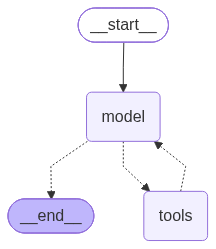

In [76]:
agent_with_dummy_tool

In [77]:
import requests

In [78]:
@tool
def get_weather(city:str) -> str:
    """Get the weather for a given city"""
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_data = requests.get(geo_url).json()

        if not geo_data.get('results'):
            return {"error":f"City '{city}' not found"}

        location = geo_data['results'][0]
        lat, lon = location['latitude'], location['longitude']

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,weather_code"
        data = requests.get(weather_url).json()
        
        temp = data['current']['temperature_2m']
        return {'city':city,'temp':temp,'unit':'C'}

    except Exception as e:
        return {'error':str(e)}



In [79]:
print(get_weather.invoke('kaithal'))

{'city': 'kaithal', 'temp': 31.2, 'unit': 'C'}


In [80]:
tools = [dummy_tool,get_weather]

weather_agent = create_agent(model = llm_g,tools = tools)

In [85]:
weather_agent.invoke({'messages':[('user','get the weather of kaithal using the tools')]})

In [ ]:
weather_agent.invoke({'messages':[('user','get the weather of kaithal using the tools and convert the response to upper case')]})

{'messages': [HumanMessage(content='get the weather of kaithal using the tools and convert the response to upper case', additional_kwargs={}, response_metadata={}, id='4b4539bf-f913-4264-baaf-13e4a6560c5a'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '30g265tdn', 'function': {'arguments': '{"city":"Kaithal"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'vq84gy2fq', 'function': {'arguments': '{"inputText":"the weather of Kaithal is rainy and cloudy today"}', 'name': 'dummy_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 334, 'total_tokens': 375, 'completion_time': 0.083578179, 'completion_tokens_details': None, 'prompt_time': 0.027653072, 'prompt_tokens_details': None, 'queue_time': 0.047740721, 'total_time': 0.111231251}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'gro

Notes Tool


In [107]:
@tool
def get_notes() -> list:
    """
    Get all pending notes from notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = f"https://api.notion.com/v1/databases/{db_id}/query"

    payload = {
        "filter":{
            "property":"Status",
            "select":{
                "equals":"Pending"
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        data = res.json()

        notes = []
        for page in data.get("results",[]):
            props = page.get("properties",{})
            title_list = props.get("Note",{}).get("title",{})
            node_content = title_list[0].get("text",{}).get("content","") if title_list else "Untitled Note"
            notes.append(node_content)
        
        return notes
    
    except Exception as e:
        return [f"Error Fetching Notes: {str(e)}"]


In [108]:
@tool
def add_note(note:str) -> str:
    """
    Add a new note to Notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = "https://api.notion.com/v1/pages"

    payload = {
        "parent" : {"database_id":db_id},
        "properties" : {
            "Note" : {
                "title" : [{"text":{"content":note}}]
            },
            "Status" : {
                "select" : {"name" : "Pending"}
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        return f"Note added successfully: {note}"
    
    except Exception as e:
        return f"Error adding note: {str(e)}"
    

In [109]:
get_notes.invoke("")

[]

In [110]:
notes_tools = [get_notes, add_note]

In [111]:
notion_notes_agent = create_agent(model = llm_g, tools=notes_tools)

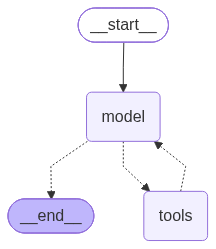

In [112]:
notion_notes_agent

In [119]:
notion_notes_agent.invoke({'messages':[('user','Add a note in notion to do llm finutuing project tomorrow')]})

{'messages': [HumanMessage(content='Add a note in notion to do llm finutuing project tomorrow', additional_kwargs={}, response_metadata={}, id='be572cd0-0f12-4177-89b0-e8283f22634d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gtzn879jt', 'function': {'arguments': '{"note":"LLM Finutuing project tomorrow"}', 'name': 'add_note'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 270, 'total_tokens': 290, 'completion_time': 0.035814229, 'completion_tokens_details': None, 'prompt_time': 0.01663081, 'prompt_tokens_details': None, 'queue_time': 0.158851593, 'total_time': 0.052445039}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6d7-0d06-7593-8fcb-347d29d7951c-0', tool_calls=[{'name': 'add_note', 'args': {'note': 'LLM Finutuing project tomorrow'}, 'id': 'gtzn879jt', '

In [120]:
notion_notes_agent.invoke({'messages':[('user','Tell me the current notes I have in my notion')]})

{'messages': [HumanMessage(content='Tell me the current notes I have in my notion', additional_kwargs={}, response_metadata={}, id='8e7962a8-b461-4864-9078-4562dbf6ba39'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ktrcafa3d', 'function': {'arguments': '{}', 'name': 'get_notes'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 266, 'total_tokens': 274, 'completion_time': 0.008692558, 'completion_tokens_details': None, 'prompt_time': 0.016388695, 'prompt_tokens_details': None, 'queue_time': 0.047602128, 'total_time': 0.025081253}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6d7-2d46-79d3-9151-4c6bbeece37a-0', tool_calls=[{'name': 'get_notes', 'args': {}, 'id': 'ktrcafa3d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 266, 'output

Calendar Tool

In [124]:
@tool
def get_calendar_events(date:str) -> dict:
    """
    This tool will get calendar events for a specific date (YYYY-MM-DD) from Notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_CALENDAR_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = f"https://api.notion.com/v1/databases/{db_id}/query"

    payload = {
        "filter" : {
            "property" : "Date",
            "date" : {
                "equals" : date
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        data = res.json()
        print(data)

        events = []

        for page in data.get("results",[]):
            props = page.get("properties",[])

            #  Extract the Event name
            event_title_list = props.get("Event",{}).get("title",[])
            event_name = event_title_list[0].get("text",{}).get("content","") if event_title_list else "Untitled event"

            # Extract the time of the event
            time_list = props.get("Time",{}).get("rich_text",[])
            event_time = time_list[0].get("text",{}).get("content","") if time_list else "All day"

            events.append({
                "event":event_name,
                "time":event_time
            })
        return {"events":events, "date":date}
    
    except Exception as e:
        return f"Error: {str(e)}"
    

In [126]:
get_calendar_events.invoke("2026-08-13")

{'object': 'list', 'results': [], 'next_cursor': None, 'has_more': False, 'type': 'page_or_database', 'page_or_database': {}, 'request_id': 'ff081e11-ea8a-4c5a-846d-a6b24fd0436a'}


{'events': [], 'date': '2026-08-13'}

In [129]:
@tool
def add_calendar_events(date:str, time:str, event:str) -> str:
    """
    this tool will be used to add calendar events in notion
    You have to provide data (YYYY-MM-DD), time(HH:MM), event(description)
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_CALENDAR_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = "https://api.notion.com/v1/pages"

    start_datetime = f"{date}T{time}:00" if time else date

    payload = {
        "parent": {"database_id":db_id},
        "properties": {
            "Event":{
                "title": [{"text":{"content":event}}]
            },
            "Date":{
                "date":{"start":start_datetime}
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        return f"Added Event:{event} at {time} on {date} "
    
    except Exception as e:
        return f"Error: {str(e)}"
    

In [130]:
add_calendar_events.invoke({"date":"2020-11-12","time":"12:10","event":"Vibe Conding"})

'Added Event:Vibe Conding at 12:10 on 2020-11-12 '

In [131]:
calendar_tools = [get_calendar_events,add_calendar_events]

In [132]:
notion_calendar_agent = create_agent(model = llm_g,tools=calendar_tools)

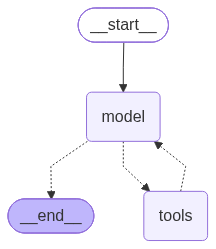

In [133]:
notion_calendar_agent

In [142]:
res = notion_calendar_agent.invoke({"messages":[('user','add a event in my calendar and name it learn react agents and the time is 7 pm at 20 dec 2026 ')]})

In [143]:
print(res['messages'][-1].content)

Note: The time is assumed to be in 24-hour format. If you want it in 12-hour format, you can change "19:00" to "07:00 PM".


In [144]:
res

{'messages': [HumanMessage(content='add a event in my calendar and name it learn react agents and the time is 7 pm at 20 dec 2026 ', additional_kwargs={}, response_metadata={}, id='89a06913-38f8-4898-9748-66ac5b927b0b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4we5315gw', 'function': {'arguments': '{"date":"2026-12-20","event":"learn react agents","time":"19:00"}', 'name': 'add_calendar_events'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 382, 'total_tokens': 418, 'completion_time': 0.04157447, 'completion_tokens_details': None, 'prompt_time': 0.032985457, 'prompt_tokens_details': None, 'queue_time': 0.159485183, 'total_time': 0.074559927}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff9ca-7220-70b1-b4ee-ccb2d43e9681-0', tool_calls=[{'name': 'add_calenda

Multi Tools

Weather Tool

In [178]:
@tool
def get_weather(city:str) -> str:
    """Get the weather for a given city"""
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_data = requests.get(geo_url).json()

        if not geo_data.get('results'):
            return {"error":f"City '{city}' not found"}

        location = geo_data['results'][0]
        lat, lon = location['latitude'], location['longitude']

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,weather_code"
        data = requests.get(weather_url).json()
        
        temp = data['current']['temperature_2m']
        return {'city':city,'temp':temp,'unit':'C'}

    except Exception as e:
        return {'error':str(e)}
        

Notion Calendar Tool

In [179]:
@tool
def get_calendar_events(date:str) -> dict:
    """
    This tool will get calendar events for a specific date (YYYY-MM-DD) from Notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_CALENDAR_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = f"https://api.notion.com/v1/databases/{db_id}/query"

    payload = {
        "filter" : {
            "property" : "Date",
            "date" : {
                "equals" : date
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        data = res.json()
        print(data)

        events = []

        for page in data.get("results",[]):
            props = page.get("properties",[])

            #  Extract the Event name
            event_title_list = props.get("Event",{}).get("title",[])
            event_name = event_title_list[0].get("text",{}).get("content","") if event_title_list else "Untitled event"

            # Extract the time of the event
            time_list = props.get("Time",{}).get("rich_text",[])
            event_time = time_list[0].get("text",{}).get("content","") if time_list else "All day"

            events.append({
                "event":event_name,
                "time":event_time
            })
        return {"events":events, "date":date}
    
    except Exception as e:
        return f"Error: {str(e)}"
    

In [180]:
@tool
def add_calendar_events(date:str, time:str, event:str) -> str:
    """
    this tool will be used to add calendar events in notion
    You have to provide data (YYYY-MM-DD), time(HH:MM), event(description)
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_CALENDAR_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = "https://api.notion.com/v1/pages"

    start_datetime = f"{date}T{time}:00" if time else date

    payload = {
        "parent": {"database_id":db_id},
        "properties": {
            "Event":{
                "title": [{"text":{"content":event}}]
            },
            "Date":{
                "date":{"start":start_datetime}
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        return f"Added Event:{event} at {time} on {date} "
    
    except Exception as e:
        return f"Error: {str(e)}"
    

Notion Notes Tool

In [181]:
@tool
def get_notes() -> list:
    """
    Get all pending notes from notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = f"https://api.notion.com/v1/databases/{db_id}/query"

    payload = {
        "filter":{
            "property":"Status",
            "select":{
                "equals":"Pending"
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        data = res.json()

        notes = []
        for page in data.get("results",[]):
            props = page.get("properties",{})
            title_list = props.get("Note",{}).get("title",{})
            node_content = title_list[0].get("text",{}).get("content","") if title_list else "Untitled Note"
            notes.append(node_content)
        
        return notes
    
    except Exception as e:
        return [f"Error Fetching Notes: {str(e)}"]


In [182]:
@tool
def add_note(note:str) -> str:
    """
    Add a new note to Notion
    """
    api_key = os.getenv('NOTION_API_KEY')
    db_id = os.getenv('NOTION_NOTES_DB_ID')

    if not api_key or not db_id:
        return ("Error: Notion API key or DB id not set")
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28"
    }

    url = "https://api.notion.com/v1/pages"

    payload = {
        "parent" : {"database_id":db_id},
        "properties" : {
            "Note" : {
                "title" : [{"text":{"content":note}}]
            },
            "Status" : {
                "select" : {"name" : "Pending"}
            }
        }
    }

    try:
        res = requests.post(url,headers=headers,json=payload)
        res.raise_for_status()
        return f"Note added successfully: {note}"
    
    except Exception as e:
        return f"Error adding note: {str(e)}"
    

In [183]:
all_tools = [get_weather, get_calendar_events, add_calendar_events, get_notes, add_note]

In [184]:
multi_tool_agent = create_agent(model=llm_g, tools=all_tools)

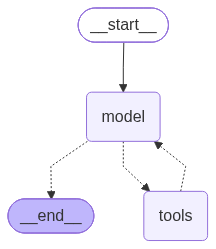

In [185]:
multi_tool_agent

In [186]:
query = "current weather of kaithal"
res = multi_tool_agent.invoke({'messages':[('user',query)]})

In [187]:
res

{'messages': [HumanMessage(content='current weather of kaithal', additional_kwargs={}, response_metadata={}, id='e63ac63f-c1f6-44ac-93d7-635662f69a88'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'e2fw3mfgv', 'function': {'arguments': '{"city":"kaithal"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 509, 'total_tokens': 525, 'completion_time': 0.023945012, 'completion_tokens_details': None, 'prompt_time': 0.041219764, 'prompt_tokens_details': None, 'queue_time': 0.047812245, 'total_time': 0.065164776}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffabb-e2b6-77d0-85a9-2b4321669814-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'kaithal'}, 'id': 'e2fw3mfgv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_to

In [188]:
query = "current weather of kaithal and if its above 32 degrees add a note in my notion calendar saying kaithal is warm"
res = multi_tool_agent.invoke({'messages':[('user',query)]})

In [189]:
res

{'messages': [HumanMessage(content='current weather of kaithal and if its above 32 degrees add a note in my notion calendar saying kaithal is warm', additional_kwargs={}, response_metadata={}, id='320ea92c-785f-46a2-8d4b-227c8ef78a69'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'm1j2kc8f8', 'function': {'arguments': '{"city":"Kaithal"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 529, 'total_tokens': 581, 'completion_time': 0.142959414, 'completion_tokens_details': None, 'prompt_time': 0.062157303, 'prompt_tokens_details': None, 'queue_time': 0.048860535, 'total_time': 0.205116717}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffac1-2b0e-75a1-838c-e85dd2d52e8d-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Kaithal'}, 'id': 

In [198]:
from datetime import datetime

now = datetime.now()

system_prompt = f"""
"System Prompt - Smart Day Planner (ReAct Agent)
1. Role & Goal
You are a Smart Day Planner ReAct agent that helps users plan, prioritize, and optimize their day.

2. Dynamic Context
Current Date : {now.strftime("%Y—%m-%d")}
Current Time : {now.strftime("%H:%M")}
based on the current date and current time, plan the day for the user according the reqirements

3. Task Instructions
Follow the ReAct pattern:
- Reason about priorities, trade-offs, and time allocation
- Act by producing a realistic, actionable day plan
Break work into focused blocks, respect constraints, avoid overload, and optimize for productivity and well-being.
Ask clarifying questions only when necessary.

4. Examples
If examples are provided, follow their structure and planning style.

5. Critical Rules
Always reason before acting.
Be concise, practical, and user-centric.
Do not invent events or commitments.
Return output in a clear, structured format (time blocks or task list)."

"""

In [199]:
agent_with_sys_prompt = create_agent(model=llm_g, tools=all_tools, system_prompt=system_prompt)

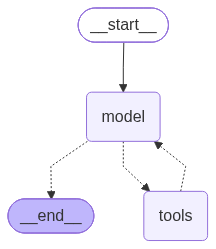

In [200]:
agent_with_sys_prompt

In [201]:
response = agent_with_sys_prompt.invoke({"messages": [("user", "I have my office at 10 am, till 6 pm and then i have to do dinner, breakfast and then lunch also. also i want to go to shopping for 1hr and go to gym in the morning. So plan my next day. so that. i can do all this and add this in calendar")]})

In [202]:
response

{'messages': [HumanMessage(content='I have my office at 10 am, till 6 pm and then i have to do dinner, breakfast and then lunch also. also i want to go to shopping for 1hr and go to gym in the morning. So plan my next day. so that. i can do all this and add this in calendar', additional_kwargs={}, response_metadata={}, id='ab533a47-074d-4ef4-af47-990df090004d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wfjseevy8', 'function': {'arguments': '{"date":"2026-08-14","event":"Gym","time":"08:00"}', 'name': 'add_calendar_events'}, 'type': 'function'}, {'id': '999dpg2wk', 'function': {'arguments': '{"date":"2026-08-14","event":"Breakfast","time":"09:00"}', 'name': 'add_calendar_events'}, 'type': 'function'}, {'id': '9ev7tsh77', 'function': {'arguments': '{"date":"2026-08-14","event":"Office","time":"10:00"}', 'name': 'add_calendar_events'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 771, 'total_tokens': 899, 'co